# K-Means on PCA-Reduced Data (5 Components)

This notebook runs K-Means (k=2) on X_pca_5.csv and logs metrics to clustering_summary.csv.

In [5]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import mode
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [6]:
N_COMPONENTS = 5

project_root = Path.cwd()
if not (project_root / 'data' / 'processed').exists() and (project_root.parent / 'data' / 'processed').exists():
    project_root = project_root.parent

processed_dir = project_root / 'data' / 'processed'
summary_path = project_root / 'results' / 'metrics' / 'clustering_summary.csv'

X = pd.read_csv(processed_dir / f'X_pca_{N_COMPONENTS}.csv')
y = pd.read_csv(processed_dir / 'y_sample.csv').squeeze()

print(f'Loaded X shape: {X.shape}')
print(f'Loaded y shape: {y.shape}')

Loaded X shape: (200000, 5)
Loaded y shape: (200000,)


In [7]:
train_start = time.time()
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=20)
kmeans.fit(X)
training_time = time.time() - train_start

pred_start = time.time()
y_pred = kmeans.predict(X)
prediction_time = time.time() - pred_start

mapped_labels = np.zeros_like(y_pred)
for cluster_id in range(2):
    mask = y_pred == cluster_id
    mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]

accuracy = accuracy_score(y, mapped_labels) * 100

print(f'Training time: {training_time:.4f} sec')
print(f'Prediction time: {prediction_time:.4f} sec')
print(f'Iterations: {kmeans.n_iter_}')
print(f'Accuracy (mapped clusters): {accuracy:.4f}%')

Training time: 2.7528 sec
Prediction time: 0.0147 sec
Iterations: 14
Accuracy (mapped clusters): 55.6780%


In [4]:
new_row = pd.DataFrame([{
    'method': f'KMeans PCA {N_COMPONENTS}',
    'dataset_version': 'sample_200k',
    'n_clusters': 2,
    'n_rows': X.shape[0],
    'n_features': X.shape[1],
    'training_time_seconds': training_time,
    'prediction_time_seconds': prediction_time,
    'iterations': kmeans.n_iter_,
    'accuracy': accuracy,
    'silhouette_score': None,
    'davies_bouldin': None,
    'compactness': None,
    'separation': None
}])

if summary_path.exists():
    df_summary = pd.read_csv(summary_path)
    df_summary = df_summary[~((df_summary['method'] == f'KMeans PCA {N_COMPONENTS}') & (df_summary['dataset_version'] == 'sample_200k'))]
    df_summary = pd.concat([df_summary, new_row], ignore_index=True)
else:
    df_summary = new_row

df_summary.to_csv(summary_path, index=False)
print(df_summary.tail().to_string(index=False))

        method    dataset_version  n_clusters   n_rows  n_features  training_time_seconds  prediction_time_seconds  iterations  accuracy silhouette_score davies_bouldin compactness separation
KMeans Full 28 HIGGS.csv.gz(full)           2 10721302          28              17.719350                 2.456887          18  55.68153              NaN            NaN         NaN        NaN
KMeans Full 28        sample_200k           2   200000          28               1.632142                 0.024272           6  55.63850              NaN            NaN         NaN        NaN
  KMeans PCA 2        sample_200k           2   200000           2               4.209194                 0.020219          18  55.61950              NaN            NaN         NaN        NaN
  KMeans PCA 5        sample_200k           2   200000           5               5.958061                 0.018394          14  55.67800             None           None        None       None


## Scatter Plot: K-Means Clusters on PCA-5 Data (PC1 vs PC2)

This plot uses the first two PCA components from the 5-component dataset and colors points by assigned K-Means cluster.

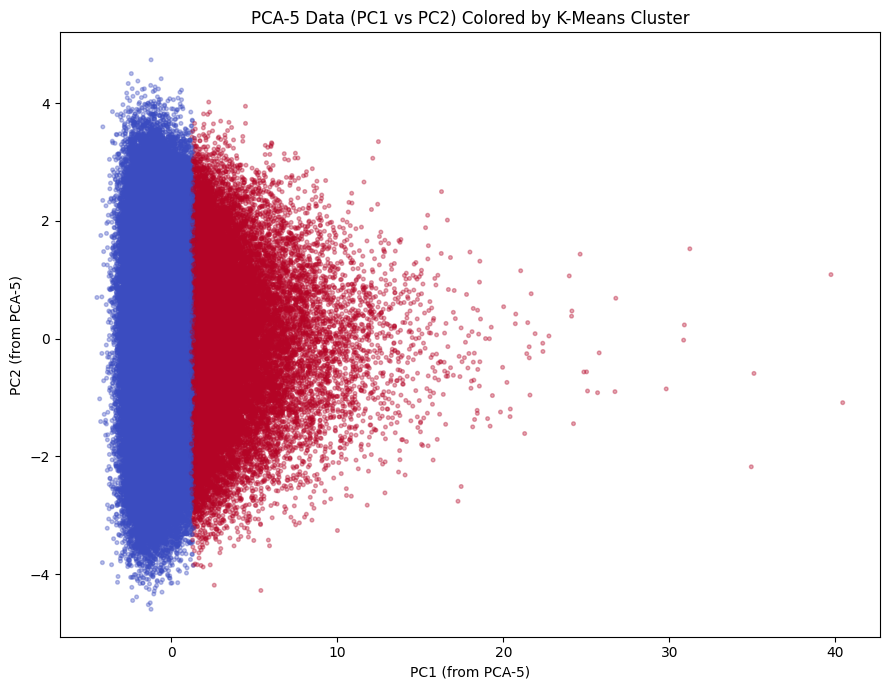

Saved visualization: results/visualizations/kmeans_pca5_cluster_scatter.png


In [8]:
import matplotlib.pyplot as plt

viz_dir = project_root / 'results' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 7))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_pred, cmap='coolwarm', alpha=0.35, s=7)
plt.xlabel('PC1 (from PCA-5)')
plt.ylabel('PC2 (from PCA-5)')
plt.title('PCA-5 Data (PC1 vs PC2) Colored by K-Means Cluster')
plt.tight_layout()
plt.savefig(viz_dir / 'kmeans_pca5_cluster_scatter.png', dpi=150)
plt.show()

print('Saved visualization: results/visualizations/kmeans_pca5_cluster_scatter.png')

### Interpretation (PCA-5 Scatter)

- The plot shows partial separation structure in the first two components, but there is still noticeable overlap between cluster colors.
- This overlap is consistent with the moderate clustering accuracy and indicates that K-Means is partitioning a continuous distribution rather than cleanly separated classes.
- Outlying points are present and can influence centroid placement, which may affect stability across runs.